In [117]:
# Importamos las librerias
# Imputer fue eliminado de sklearn; usar SimpleImputer (sklearn.impute)
# pip install scikit-learn   # si no lo tienes
from sklearn.impute import SimpleImputer  # reemplazo de Imputer

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb

In [118]:
# Esta linea permite que los graficos sean renderizados directamente en nuestro Notebook
## Carguemos en un pandas dataframe nuestra base de datos
%matplotlib inline

## Carguemos en un pandas dataframe nuestra base de datos

<div class="alert alert-block alert-info" style="margin-top: 20px">
  <code>pd.read_csv</code> es el metodo que nos permite importar los datos desde un CSV y cargarlo en un **DataFrame**, que es la estructura de base de Pandas
</div>

In [119]:
movies = pd.read_csv('data/peliculas_3169fc13-a8ff-4b9a-b125-3a94c1e5f6d4.csv',encoding='utf-8')

In [120]:
type(movies)

pandas.core.frame.DataFrame

In [121]:
movies.head()

,movie_title,title_year,color,aspect_ratio,duration,language,country,duration.1,genres,content_rating,plot_keywords,director_name,actor_1_name,actor_2_name,actor_3_name,cast_total_facebook_likes,budget,imdb_score,gross
0,Avatar,2009.0,Color,1.78,178.0,English,USA,178.0,Action|Adventure|Fantasy|Sci-Fi,PG-13,avatar|future|marine|native|paraplegic,James Cameron,CCH Pounder,Joel David Moore,Wes Studi,4834,237000000.0,7.9,760505847.0
1,Pirates of the Caribbean: At World's End,2007.0,Color,2.35,169.0,English,USA,169.0,Action|Adventure|Fantasy,PG-13,goddess|marriage ceremony|marriage proposal|pi...,Gore Verbinski,Johnny Depp,Orlando Bloom,Jack Davenport,48350,300000000.0,7.1,309404152.0
2,Spectre,2015.0,Color,2.35,148.0,English,UK,148.0,Action|Adventure|Thriller,PG-13,bomb|espionage|sequel|spy|terrorist,Sam Mendes,Christoph Waltz,Rory Kinnear,Stephanie Sigman,11700,245000000.0,6.8,200074175.0
3,The Dark Knight Rises,2012.0,Color,2.35,164.0,English,USA,164.0,Action|Thriller,PG-13,deception|imprisonment|lawlessness|police offi...,Christopher Nolan,Tom Hardy,Christian Bale,Joseph Gordon-Levitt,106759,250000000.0,8.5,448130642.0
4,Star Wars: Episode VII - The Force Awakens ...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Documentary,NaN,NaN,Doug Walker,Doug Walker,Rob Walker,NaN,143,NaN,7.1,NaN


In [122]:
# Cuantas lineas y columnas tiene nuestro dataframe
### Un dataframe es una estructura de datos que se compone de los elementos siguientes
movies.shape

(5043, 19)

<div class="alert alert-block alert-info" style="margin-top: 20px">
  Un dataframe es una estructura de datos que se compone de los elementos siguientes
</div> 

<img src="img/dataframe_structure.png" style="margin:0 auto;clear:both">

In [123]:
#visualizemos las columnas
movies.columns

Index(['movie_title', 'title_year', 'color', 'aspect_ratio', 'duration',
       'language', 'country', 'duration.1', 'genres', 'content_rating',
       'plot_keywords', 'director_name', 'actor_1_name', 'actor_2_name',
       'actor_3_name', 'cast_total_facebook_likes', 'budget', 'imdb_score',
       'gross'],
      dtype='object')

In [124]:
movies.index

RangeIndex(start=0, stop=5043, step=1)

In [125]:
columna1 = movies['movie_title']
columna1.head()

0                                              Avatar 
1            Pirates of the Caribbean: At World's End 
2                                             Spectre 
3                               The Dark Knight Rises 
4    Star Wars: Episode VII - The Force Awakens    ...
Name: movie_title, dtype: object

In [126]:
linea = movies.loc[10,:]
linea

movie_title                                Batman v Superman: Dawn of Justice 
title_year                                                              2016.0
color                                                                    Color
aspect_ratio                                                              2.35
duration                                                                 183.0
language                                                               English
country                                                                    USA
duration.1                                                               183.0
genres                                                 Action|Adventure|Sci-Fi
content_rating                                                           PG-13
plot_keywords                based on comic book|batman|sequel to a reboot|...
director_name                                                      Zack Snyder
actor_1_name                                        

In [127]:
movies.loc[:,'movie_title'].head()

0                                              Avatar 
1            Pirates of the Caribbean: At World's End 
2                                             Spectre 
3                               The Dark Knight Rises 
4    Star Wars: Episode VII - The Force Awakens    ...
Name: movie_title, dtype: object

## Intentemos inspeccionar nuestros datos y entenderlos mejor 

In [128]:
movies.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5043 entries, 0 to 5042
Data columns (total 19 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   movie_title                5043 non-null   object 
 1   title_year                 4935 non-null   float64
 2   color                      5024 non-null   object 
 3   aspect_ratio               4714 non-null   float64
 4   duration                   5028 non-null   float64
 5   language                   5029 non-null   object 
 6   country                    5038 non-null   object 
 7   duration.1                 5028 non-null   float64
 8   genres                     5043 non-null   object 
 9   content_rating             4740 non-null   object 
 10  plot_keywords              4890 non-null   object 
 11  director_name              4939 non-null   object 
 12  actor_1_name               5036 non-null   object 
 13  actor_2_name               5030 non-null   objec

<div class="alert alert-block alert-info" style="margin-top: 20px">
  A diferencia de Numpy, Pandas permite cargar no solo datos numericos pero tambien **datos de texto** que vemos por ejemplo en las columnas de actores y **mezclar distintos tipos de datos**.
<ul>
 <li>int64 y float64 corresponden a los mismos dtypes de Numpy </li>
 <li> object es el dtype que permite manejar datos de texto </li>
</ul>
</div>

In [129]:
# columnas númericas y columnas de texto
movies.dtypes == float

movie_title                  False
title_year                    True
color                        False
aspect_ratio                  True
duration                      True
language                     False
country                      False
duration.1                    True
genres                       False
content_rating               False
plot_keywords                False
director_name                False
actor_1_name                 False
actor_2_name                 False
actor_3_name                 False
cast_total_facebook_likes    False
budget                        True
imdb_score                    True
gross                         True
dtype: bool

In [130]:
movies.dtypes == int

movie_title                  False
title_year                   False
color                        False
aspect_ratio                 False
duration                     False
language                     False
country                      False
duration.1                   False
genres                       False
content_rating               False
plot_keywords                False
director_name                False
actor_1_name                 False
actor_2_name                 False
actor_3_name                 False
cast_total_facebook_likes    False
budget                       False
imdb_score                   False
gross                        False
dtype: bool

In [131]:
movies.dtypes == object

movie_title                   True
title_year                   False
color                         True
aspect_ratio                 False
duration                     False
language                      True
country                       True
duration.1                   False
genres                        True
content_rating                True
plot_keywords                 True
director_name                 True
actor_1_name                  True
actor_2_name                  True
actor_3_name                  True
cast_total_facebook_likes    False
budget                       False
imdb_score                   False
gross                        False
dtype: bool

In [132]:
num = (movies.dtypes == float) | (movies.dtypes == int)
num

movie_title                  False
title_year                    True
color                        False
aspect_ratio                  True
duration                      True
language                     False
country                      False
duration.1                    True
genres                       False
content_rating               False
plot_keywords                False
director_name                False
actor_1_name                 False
actor_2_name                 False
actor_3_name                 False
cast_total_facebook_likes    False
budget                        True
imdb_score                    True
gross                         True
dtype: bool

In [133]:
num.index

Index(['movie_title', 'title_year', 'color', 'aspect_ratio', 'duration',
       'language', 'country', 'duration.1', 'genres', 'content_rating',
       'plot_keywords', 'director_name', 'actor_1_name', 'actor_2_name',
       'actor_3_name', 'cast_total_facebook_likes', 'budget', 'imdb_score',
       'gross'],
      dtype='object')

In [134]:
for el in num.index:
    print(el)

movie_title
title_year
color
aspect_ratio
duration
language
country
duration.1
genres
content_rating
plot_keywords
director_name
actor_1_name
actor_2_name
actor_3_name
cast_total_facebook_likes
budget
imdb_score
gross


In [135]:
num_cols = [c for c in num.index if num[c]]

In [136]:
num_cols

['title_year',
 'aspect_ratio',
 'duration',
 'duration.1',
 'budget',
 'imdb_score',
 'gross']

In [137]:
movies.dtypes == object

movie_title                   True
title_year                   False
color                         True
aspect_ratio                 False
duration                     False
language                      True
country                       True
duration.1                   False
genres                        True
content_rating                True
plot_keywords                 True
director_name                 True
actor_1_name                  True
actor_2_name                  True
actor_3_name                  True
cast_total_facebook_likes    False
budget                       False
imdb_score                   False
gross                        False
dtype: bool

In [138]:
obj = (movies.dtypes == object)
obj_cols = [c for c in obj.index if obj[c]]

In [139]:
obj_cols

['movie_title',
 'color',
 'language',
 'country',
 'genres',
 'content_rating',
 'plot_keywords',
 'director_name',
 'actor_1_name',
 'actor_2_name',
 'actor_3_name']

In [140]:
num_cols

['title_year',
 'aspect_ratio',
 'duration',
 'duration.1',
 'budget',
 'imdb_score',
 'gross']

In [141]:
movies_num = movies[num_cols]

In [142]:
# Estadísticas de las columnas númericas
movies_num.describe()

,title_year,aspect_ratio,duration,duration.1,budget,imdb_score,gross
count,4935.000000,4714.000000,5028.000000,5028.000000,4.551000e+03,5043.000000,4.159000e+03
mean,2002.470517,2.220403,107.201074,107.201074,3.975262e+07,6.442138,4.846841e+07
std,12.474599,1.385113,25.197441,25.197441,2.061149e+08,1.125116,6.845299e+07
min,1916.000000,1.180000,7.000000,7.000000,2.180000e+02,1.600000,1.620000e+02
25%,1999.000000,1.850000,93.000000,93.000000,6.000000e+06,5.800000,5.340988e+06
50%,2005.000000,2.350000,103.000000,103.000000,2.000000e+07,6.600000,2.551750e+07
75%,2011.000000,2.350000,118.000000,118.000000,4.500000e+07,7.200000,6.230944e+07
max,2016.000000,16.000000,511.000000,511.000000,1.221550e+10,9.500000,7.605058e+08


In [143]:
# Estadísticas de las columnas de texto

Para hacer nuestro primer modelo más simple para este trabajaremos solo con las columnas númericas.

<Axes: >

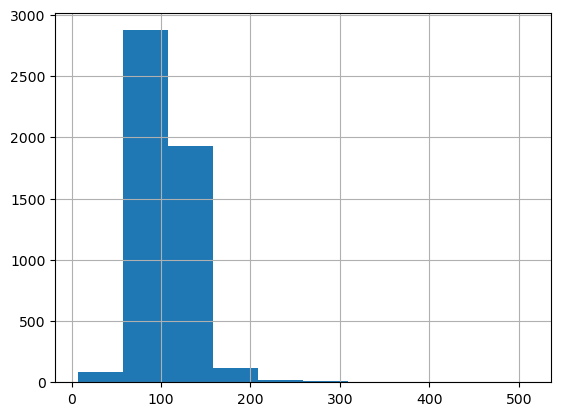

In [144]:
movies_num['duration'].hist()

<Axes: >

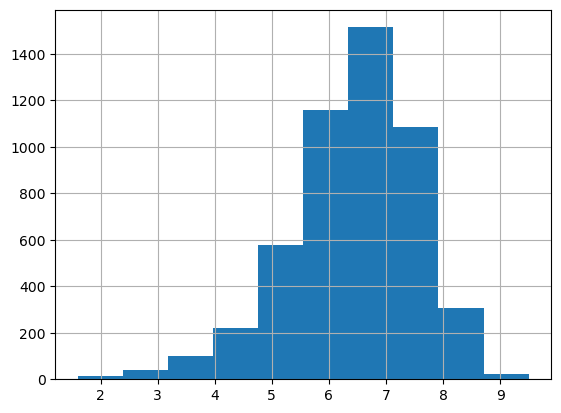

In [145]:
movies_num['imdb_score'].hist()

<Axes: >

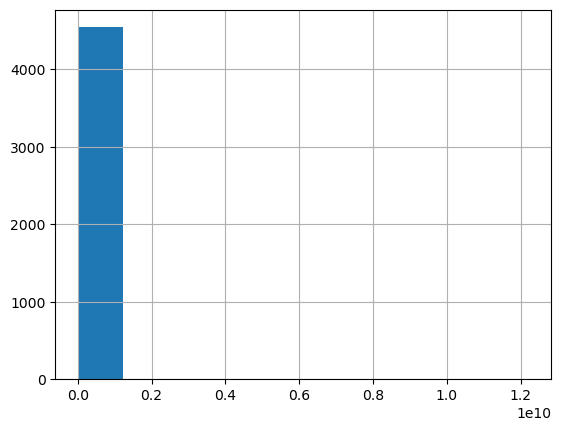

In [146]:
movies_num['budget'].hist()

<div class="alert alert-block alert-info" style="margin-top: 20px">
Para poder debuggear esta situación utilizaremos una tecnica muy tipica de pandas que se llama **boolean filtering**. Basicamente construimos una serie de booleanos con el mismo indice que nuestro dataframe (la serie clasicamente la llamaremos mask).
</div>

In [147]:
mask = (movies_num['budget'] > 1e9)

In [148]:
movies[mask]

,movie_title,title_year,color,aspect_ratio,duration,language,country,duration.1,genres,content_rating,plot_keywords,director_name,actor_1_name,actor_2_name,actor_3_name,cast_total_facebook_likes,budget,imdb_score,gross
2323,Princess Mononoke,1997.0,Color,1.85,134.0,Japanese,Japan,134.0,Adventure|Animation|Fantasy,PG-13,anime|cult film|forest|princess|studio ghibli,Hayao Miyazaki,Minnie Driver,Jada Pinkett Smith,Billy Crudup,2710,2.400000e+09,8.4,2298191.0
2334,Steamboy,2004.0,Color,1.85,103.0,Japanese,Japan,103.0,Action|Adventure|Animation|Family|Sci-Fi|Thriller,PG-13,19th century|ball|boy|inventor|steam,Katsuhiro Ôtomo,William Hootkins,Robin Atkin Downes,Rosalind Ayres,991,2.127520e+09,6.9,410388.0
2988,The Host,2006.0,Color,1.85,110.0,Korean,South Korea,110.0,Comedy|Drama|Horror|Sci-Fi,R,daughter|han river|monster|river|seoul,Joon-ho Bong,Doona Bae,Kang-ho Song,Ah-sung Ko,1173,1.221550e+10,7.0,2201412.0
3005,Fateless,2005.0,Color,2.35,134.0,Hungarian,Hungary,134.0,Drama|Romance|War,R,bus|death|gay slur|hatred|jewish,Lajos Koltai,Marcell Nagy,Péter Fancsikai,Bálint Péntek,11,2.500000e+09,7.1,195888.0
3423,Akira,1988.0,Color,1.85,124.0,Japanese,Japan,124.0,Action|Animation|Sci-Fi,R,based on manga|biker gang|gifted child|post th...,Katsuhiro Ôtomo,Mitsuo Iwata,Takeshi Kusao,Tesshô Genda,28,1.100000e+09,8.1,439162.0
3859,Lady Vengeance,2005.0,Color,2.35,112.0,Korean,South Korea,112.0,Crime|Drama,R,cake|christian|lesbian sex|oral sex|pregnant s...,Chan-wook Park,Min-sik Choi,Yeong-ae Lee,Hye-jeong Kang,907,4.200000e+09,7.7,211667.0


<img src="img/akira.png" width="1000" style="margin:0 auto;clear:both">

 Tenemos un problema de limpieza de los datos. La BDD fue creada sin diferenciar:
- La moneda en la que se ingresaba el presupuesto y el ingreso. 
- La zona (país/mundial) en la que se registro el ingreso

In [149]:
# Importar BBDD thenumbers.com## Ahora manejaremos los datos faltantes (nulos o NaN). 

In [150]:
financials = pd.read_csv('data/thenumbers_5ab682a6-c23a-4dfc-901c-ae93c625aa01.csv')

In [151]:
financials = financials[['movie_title','production_budget','worldwide_gross']]

In [152]:
gross_opening = pd.read_csv('data/opening_df_9e6c8eb2-0f13-4dac-8f82-40dce349a161.csv')

In [153]:
financials.shape

(4341, 3)

In [154]:
movies.shape

(5043, 19)

In [155]:
movies['movie_title']

0                                                 Avatar 
1               Pirates of the Caribbean: At World's End 
2                                                Spectre 
3                                  The Dark Knight Rises 
4       Star Wars: Episode VII - The Force Awakens    ...
                              ...                        
5038                             Signed Sealed Delivered 
5039                           The Following             
5040                                A Plague So Pleasant 
5041                                    Shanghai Calling 
5042                                   My Date with Drew 
Name: movie_title, Length: 5043, dtype: object

In [156]:
movies_num

,title_year,aspect_ratio,duration,duration.1,budget,imdb_score,gross
0,2009.0,1.78,178.0,178.0,237000000.0,7.9,760505847.0
1,2007.0,2.35,169.0,169.0,300000000.0,7.1,309404152.0
2,2015.0,2.35,148.0,148.0,245000000.0,6.8,200074175.0
3,2012.0,2.35,164.0,164.0,250000000.0,8.5,448130642.0
4,NaN,NaN,NaN,NaN,NaN,7.1,NaN
...,...,...,...,...,...,...,...
5038,2013.0,NaN,87.0,87.0,NaN,7.7,NaN
5039,NaN,16.00,43.0,43.0,NaN,7.5,NaN
5040,2013.0,NaN,76.0,76.0,1400.0,6.3,NaN
5041,2012.0,2.35,100.0,100.0,NaN,6.3,10443.0


In [157]:
movies_num = pd.concat([movies_num, movies['movie_title']],axis=1)

In [158]:
gross_opening = gross_opening.drop('Unnamed: 0',axis=1)

In [159]:
movies_v2 = pd.merge(financials,movies_num,on='movie_title',how='left')

In [160]:
movies_v2 = pd.merge(movies_v2,gross_opening,on='movie_title',how='left')

In [161]:
movies_v2.shape

(4385, 12)

## Ahora solucionaremos el problema de los datos faltantes (nulos o NaN). 

<div class="alert alert-success">
  Los datos faltantes generan problemas con muchos algoritmos de ML. Es por esto que existen distintas estrategias para lidiar con ellos.
</div>

In [162]:
help(pd.Series.value_counts)

Help on function value_counts in module pandas.core.base:

value_counts(self, normalize: 'bool' = False, sort: 'bool' = True, ascending: 'bool' = False, bins=None, dropna: 'bool' = True) -> 'Series'
    Return a Series containing counts of unique values.
    
    The resulting object will be in descending order so that the
    first element is the most frequently-occurring element.
    Excludes NA values by default.
    
    Parameters
    ----------
    normalize : bool, default False
        If True then the object returned will contain the relative
        frequencies of the unique values.
    sort : bool, default True
        Sort by frequencies when True. Preserve the order of the data when False.
    ascending : bool, default False
        Sort in ascending order.
    bins : int, optional
        Rather than count values, group them into half-open bins,
        a convenience for ``pd.cut``, only works with numeric data.
    dropna : bool, default True
        Don't include counts

In [163]:
movies_v2.notnull().apply(pd.Series.value_counts)

,movie_title,production_budget,worldwide_gross,title_year,aspect_ratio,duration,duration.1,budget,imdb_score,gross,opening_gross,screens
False,NaN,NaN,NaN,27,274,13,13,335,NaN,671,2106,2164
True,4385.0,4385.0,4385.0,4358,4111,4372,4372,4050,4385.0,3714,2279,2221


In [164]:
(movies_v2 != 0).apply(pd.Series.value_counts)

,movie_title,production_budget,worldwide_gross,title_year,aspect_ratio,duration,duration.1,budget,imdb_score,gross,opening_gross,screens
False,NaN,NaN,281,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
True,4385.0,4385.0,4104,4385.0,4385.0,4385.0,4385.0,4385.0,4385.0,4385.0,4385.0,4385.0


In [165]:
available = ((movies_v2 != 0) & (movies_v2.notnull()))

In [166]:
available.all(axis=1).value_counts()

False    2252
True     2133
Name: count, dtype: int64

No podemos entrenar nuestro algoritmo con datos cuya variable objetivo no esta definida o sea nula (valor falso). Eliminemos esas líneas.

In [167]:
mask = available['worldwide_gross']

In [168]:
movies_v2 = movies_v2[mask]

In [169]:
((movies_v2 != 0) & (movies_v2.notnull())).worldwide_gross.value_counts()

worldwide_gross
True    4104
Name: count, dtype: int64

<div class="alert alert-success">
  En el caso de las features que no son la variable objetivo una mejor solución para lidiar con los datos faltantes es <strong>remplazar estos datos por otros que sean manejables</strong> y no afecten la calidad de las predicciones. La estrategia más comun es utilizar la media de todos los ejemplos para la feature dada.
</div>

In [170]:
movies_v2 = movies_v2.drop('movie_title',axis=1)

In [171]:
movies_v2 = movies_v2.drop('duration',axis=1)

In [172]:
movies_v2 = movies_v2.drop('gross',axis=1)

In [173]:
movies_v2.head()

,production_budget,worldwide_gross,title_year,aspect_ratio,duration.1,budget,imdb_score,opening_gross,screens
0,425000000,2783918982,2009.0,1.78,178.0,237000000.0,7.9,77025481.0,3452.0
1,306000000,2058662225,NaN,NaN,NaN,NaN,7.1,NaN,NaN
2,300000000,963420425,2007.0,2.35,169.0,300000000.0,7.1,139802190.0,4362.0
3,300000000,879620923,2015.0,2.35,148.0,245000000.0,6.8,70403148.0,3929.0
4,275000000,1084439099,2012.0,2.35,164.0,250000000.0,8.5,160887295.0,4404.0


In [174]:
movies_v2 = movies_v2[available.screens]

C:\Users\57317\AppData\Local\Temp\ipykernel_34444\2334866770.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  movies_v2 = movies_v2[available.screens]


In [175]:
len(movies_v2)

2221

In [176]:
from sklearn.preprocessing import Imputer
imputer = Imputer(missing_values=np.nan, strategy='mean')

ImportError: cannot import name 'Imputer' from 'sklearn.preprocessing' (c:\Users\57317\anaconda3\envs\notebook_ejecutor_DtaScie\lib\site-packages\sklearn\preprocessing\__init__.py)

In [ ]:
values = imputer.fit_transform(movies_v2)
X = pd.DataFrame(values)
X.columns = movies_v2.columns
X.index = movies_v2.index
X.head()

,production_budget,worldwide_gross,title_year,aspect_ratio,duration.1,cast_total_facebook_likes,budget,imdb_score,opening_gross,screens
0,425000000.0,2.783919e+09,2009.0,1.78,178.0,4834.0,237000000.0,7.9,77025481.0,3452.0
2,300000000.0,9.634204e+08,2007.0,2.35,169.0,48350.0,300000000.0,7.1,139802190.0,4362.0
3,300000000.0,8.796209e+08,2015.0,2.35,148.0,11700.0,245000000.0,6.8,70403148.0,3929.0
4,275000000.0,1.084439e+09,2012.0,2.35,164.0,106759.0,250000000.0,8.5,160887295.0,4404.0
5,275000000.0,2.600021e+08,2013.0,2.35,150.0,45757.0,215000000.0,6.5,29210849.0,3904.0


In [ ]:
len(X)

2221

In [ ]:
movies_v2.values

array([[  4.25000000e+08,   2.78391898e+09,   2.00900000e+03, ...,
          7.90000000e+00,   7.70254810e+07,   3.45200000e+03],
       [  3.06000000e+08,   2.05866222e+09,              nan, ...,
          7.10000000e+00,              nan,              nan],
       [  3.00000000e+08,   9.63420425e+08,   2.00700000e+03, ...,
          7.10000000e+00,   1.39802190e+08,   4.36200000e+03],
       ..., 
       [  7.00000000e+03,   9.00000000e+02,   2.00500000e+03, ...,
          7.80000000e+00,              nan,              nan],
       [  3.96700000e+03,   1.04430000e+04,   2.01200000e+03, ...,
          6.30000000e+00,              nan,              nan],
       [  1.10000000e+03,   1.81041000e+05,   2.00400000e+03, ...,
          6.60000000e+00,              nan,              nan]])

In [ ]:
values

array([[  4.25000000e+08,   2.78391898e+09,   2.00900000e+03, ...,
          7.90000000e+00,   7.70254810e+07,   3.45200000e+03],
       [  3.06000000e+08,   2.05866222e+09,   5.91165594e+08, ...,
          7.10000000e+00,   5.91165594e+08,   5.91165594e+08],
       [  3.00000000e+08,   9.63420425e+08,   2.00700000e+03, ...,
          7.10000000e+00,   1.39802190e+08,   4.36200000e+03],
       ..., 
       [  7.00000000e+03,   9.00000000e+02,   2.00500000e+03, ...,
          7.80000000e+00,   1.90568571e+03,   1.90568571e+03],
       [  3.96700000e+03,   1.04430000e+04,   2.01200000e+03, ...,
          6.30000000e+00,   2.70237857e+03,   2.70237857e+03],
       [  1.10000000e+03,   1.81041000e+05,   2.00400000e+03, ...,
          6.60000000e+00,   2.31883063e+04,   2.31883063e+04]])

In [ ]:
X.to_csv('../vol/intermediate_results/X_opening.csv',index=False)

In [ ]:
pd.Series(X.index).apply(lambda x: inv_map.loc[x])

NameError: name 'inv_map' is not defined

In [ ]:
X.to_csv('../vol/intermediate_results/X.csv',index=False)